In [2]:
import yfinance as yf
import pandas as pd
import os
import time

# 1. Define the NIFTY 50 Tickers (NSE Symbols)
# Note: We must append '.NS' for National Stock Exchange data
nifty50_tickers = [
    "ADANIENT.NS", "ADANIPORTS.NS", "APOLLOHOSP.NS", "ASIANPAINT.NS", "AXISBANK.NS",
    "BAJAJ-AUTO.NS", "BAJFINANCE.NS", "BAJAJFINSV.NS", "BPCL.NS", "BHARTIARTL.NS",
    "BRITANNIA.NS", "CIPLA.NS", "COALINDIA.NS", "DIVISLAB.NS", "DRREDDY.NS",
    "EICHERMOT.NS", "GRASIM.NS", "HCLTECH.NS", "HDFCBANK.NS", "HDFCLIFE.NS",
    "HEROMOTOCO.NS", "HINDALCO.NS", "HINDUNILVR.NS", "ICICIBANK.NS", "ITC.NS",
    "INDUSINDBK.NS", "INFY.NS", "JSWSTEEL.NS", "KOTAKBANK.NS", "LT.NS",
    "M&M.NS", "MARUTI.NS", "NTPC.NS", "NESTLEIND.NS", "ONGC.NS",
    "POWERGRID.NS", "RELIANCE.NS", "SBILIFE.NS", "SBIN.NS", "SUNPHARMA.NS",
    "TCS.NS", "TATACONSUM.NS", "TATAMOTORS.NS", "TATASTEEL.NS", "TECHM.NS",
    "TITAN.NS", "ULTRACEMCO.NS", "UPL.NS", "WIPRO.NS"
]

print("Starting download for NIFTY 50 stocks...")

# 2. Download Data
# period="1y" fetches the last 1 year of data
# group_by='ticker' groups the data nicely by company
raw_data = yf.download(tickers=nifty50_tickers, period="5y", interval="1d", group_by='ticker', auto_adjust=True)

# 3. Reshape the Data (Critical Step)
# yfinance returns a 'MultiIndex' dataframe which is hard to use in Power BI.
# We need to stack it so 'Ticker' becomes a column, not a header.

data_list = []

for ticker in nifty50_tickers:
    # Extract data for this specific ticker
    try:
        df = raw_data[ticker].copy()
        # Add a column for the Ticker name
        df['Ticker'] = ticker
        # Reset index so 'Date' becomes a column
        df = df.reset_index()
        data_list.append(df)
    except KeyError:
        print(f"Warning: No data found for {ticker}")

# Combine all individual ticker dataframes into one big table
final_df = pd.concat(data_list)

# 4. Save to CSV
# Ensure the 'data' folder exists
os.makedirs('data', exist_ok=True)
output_path = 'data/nifty50_raw.csv'
final_df.to_csv(output_path, index=False)

print(f"Success! Data saved to {output_path}")
print(f"Total rows fetched: {len(final_df)}")
print(final_df.head())

Starting download for NIFTY 50 stocks...


[*********************100%***********************]  49 of 49 completed


Success! Data saved to data/nifty50_raw.csv
Total rows fetched: 60662
Price       Date        Open        High         Low       Close     Volume  \
0     2020-12-17  462.277083  472.801536  453.997207  458.187012  4912523.0   
1     2020-12-18  459.882888  463.075146  449.707593  454.047058  2159692.0   
2     2020-12-21  452.899898  459.633542  408.657358  428.160004  5350194.0   
3     2020-12-22  427.162435  460.431599  417.086902  457.688263  8342699.0   
4     2020-12-23  456.890187  465.668851  453.099407  462.476624  4604130.0   

Price       Ticker  
0      ADANIENT.NS  
1      ADANIENT.NS  
2      ADANIENT.NS  
3      ADANIENT.NS  
4      ADANIENT.NS  


In [1]:
import yfinance as yf
import pandas as pd
import os

# --- CONFIGURATION ---
index_ticker = "^NSEI"
folder_name = "data"
file_name = "nifty50_index.csv"

# 1. Download Data (5 Years)
print(f"Downloading data for {index_ticker}...")
# auto_adjust=True fixes splits/dividends automatically
df = yf.download(tickers=index_ticker, period="5y", interval="1d", auto_adjust=True)

# 2. Clean & Format
df = df.reset_index() # Make Date a column
df['Ticker'] = 'NIFTY 50'
df['Company Name'] = 'Nifty 50 Index'

# --- CALCULATE INDICATORS (The New Part) ---
print("Calculating Moving Averages...")

# Simple Moving Averages (SMA)
df['SMA_20'] = df['Close'].rolling(window=20).mean()
df['SMA_50'] = df['Close'].rolling(window=50).mean()
df['SMA_100'] = df['Close'].rolling(window=100).mean()
df['SMA_200'] = df['Close'].rolling(window=200).mean()

# Exponential Moving Averages (EMA)
df['EMA_12'] = df['Close'].ewm(span=12, adjust=False).mean()
df['EMA_26'] = df['Close'].ewm(span=26, adjust=False).mean()

# Rounding for neatness (Optional)
cols_to_round = ['Open', 'High', 'Low', 'Close', 'SMA_20', 'SMA_50', 'SMA_100', 'SMA_200', 'EMA_12', 'EMA_26']
# Check if columns exist before rounding to avoid errors if data is missing
existing_cols = [c for c in cols_to_round if c in df.columns]
df[existing_cols] = df[existing_cols].round(2)

# 3. Save to CSV
# Ensure the 'data' folder exists
os.makedirs(folder_name, exist_ok=True)
output_path = os.path.join(folder_name, file_name)

df.to_csv(output_path, index=False)

print("-" * 30)
print(f"SUCCESS! Data saved to: {output_path}")
print("Columns added: SMA_20, SMA_50, SMA_100, SMA_200, EMA_12, EMA_26")
print("-" * 30)

[*********************100%***********************]  1 of 1 completed

Calculating Moving Averages...
------------------------------
SUCCESS! Data saved to: data\nifty50_index.csv
Columns added: SMA_20, SMA_50, SMA_100, SMA_200, EMA_12, EMA_26
------------------------------


In [3]:
# Getting the company profiles and info
# 1. Define the NIFTY 50 Tickers
nifty50_tickers = [
    "ADANIENT.NS", "ADANIPORTS.NS", "APOLLOHOSP.NS", "ASIANPAINT.NS", "AXISBANK.NS",
    "BAJAJ-AUTO.NS", "BAJFINANCE.NS", "BAJAJFINSV.NS", "BPCL.NS", "BHARTIARTL.NS",
    "BRITANNIA.NS", "CIPLA.NS", "COALINDIA.NS", "DIVISLAB.NS", "DRREDDY.NS",
    "EICHERMOT.NS", "GRASIM.NS", "HCLTECH.NS", "HDFCBANK.NS", "HDFCLIFE.NS",
    "HEROMOTOCO.NS", "HINDALCO.NS", "HINDUNILVR.NS", "ICICIBANK.NS", "ITC.NS",
    "INDUSINDBK.NS", "INFY.NS", "JSWSTEEL.NS", "KOTAKBANK.NS", "LT.NS",
    "M&M.NS", "MARUTI.NS", "NTPC.NS", "NESTLEIND.NS", "ONGC.NS",
    "POWERGRID.NS", "RELIANCE.NS", "SBILIFE.NS", "SBIN.NS", "SUNPHARMA.NS",
    "TCS.NS", "TATACONSUM.NS", "TATAMOTORS.NS", "TATASTEEL.NS", "TECHM.NS",
    "TITAN.NS", "ULTRACEMCO.NS", "UPL.NS", "WIPRO.NS"
]

profile_data = []

print(f"Starting profile extraction for {len(nifty50_tickers)} companies...")
print("This might take 1-2 minutes as we fetch details one by one.")

# 2. Loop through each ticker to get 'info'
for ticker in nifty50_tickers:
    try:
        # Create the Ticker object
        dat = yf.Ticker(ticker)
        info = dat.info
        
        # Extract the specific fields we need
        # We use .get() to handle cases where data might be missing (avoids crashing)
        stock_info = {
            'Ticker': ticker,
            'Company_Name': info.get('longName', 'N/A'),
            'Sector': info.get('sector', 'N/A'),
            'Industry': info.get('industry', 'N/A'),
            'Market_Cap': info.get('marketCap', 0),
            'Previous_Close': info.get('previousClose', 0),
            'PE_Ratio': info.get('trailingPE', 0),
            'PB_Ratio': info.get('priceToBook', 0),
            'Dividend_Yield': info.get('dividendYield', 0),
            '52_Week_High': info.get('fiftyTwoWeekHigh', 0),
            '52_Week_Low': info.get('fiftyTwoWeekLow', 0),
            # 'Description': info.get('longBusinessSummary', 'N/A') # Optional: Can make file large
        }
        
        profile_data.append(stock_info)
        print(f"Fetched: {ticker}")
        
    except Exception as e:
        print(f"Failed to fetch {ticker}: {e}")

# 3. Create DataFrame
profile_df = pd.DataFrame(profile_data)

# 4. Save to CSV
os.makedirs('data', exist_ok=True)
output_path = 'data/nifty50_profile.csv'
profile_df.to_csv(output_path, index=False)

print("---")
print(f"Success! Profile data saved to {output_path}")
print(profile_df.head())

Starting profile extraction for 49 companies...
This might take 1-2 minutes as we fetch details one by one.
Fetched: ADANIENT.NS
Fetched: ADANIPORTS.NS
Fetched: APOLLOHOSP.NS
Fetched: ASIANPAINT.NS
Fetched: AXISBANK.NS
Fetched: BAJAJ-AUTO.NS
Fetched: BAJFINANCE.NS
Fetched: BAJAJFINSV.NS
Fetched: BPCL.NS
Fetched: BHARTIARTL.NS
Fetched: BRITANNIA.NS
Fetched: CIPLA.NS
Fetched: COALINDIA.NS
Fetched: DIVISLAB.NS
Fetched: DRREDDY.NS
Fetched: EICHERMOT.NS
Fetched: GRASIM.NS
Fetched: HCLTECH.NS
Fetched: HDFCBANK.NS
Fetched: HDFCLIFE.NS
Fetched: HEROMOTOCO.NS
Fetched: HINDALCO.NS
Fetched: HINDUNILVR.NS
Fetched: ICICIBANK.NS
Fetched: ITC.NS
Fetched: INDUSINDBK.NS
Fetched: INFY.NS
Fetched: JSWSTEEL.NS
Fetched: KOTAKBANK.NS
Fetched: LT.NS
Fetched: M&M.NS
Fetched: MARUTI.NS
Fetched: NTPC.NS
Fetched: NESTLEIND.NS
Fetched: ONGC.NS
Fetched: POWERGRID.NS
Fetched: RELIANCE.NS
Fetched: SBILIFE.NS
Fetched: SBIN.NS
Fetched: SUNPHARMA.NS
Fetched: TCS.NS
Fetched: TATACONSUM.NS
Fetched: TATAMOTORS.NS
Fetched:

In [1]:
import yfinance as yf
import pandas as pd
import os

# 1. Define the Index Ticker
# Yahoo Finance uses '^NSEI' for the NIFTY 50 Index
index_ticker = "^NSEI"

print(f"Starting download for {index_ticker}...")

# 2. Download Data
# We use the same parameters: 5 years, daily interval, auto_adjust=True
raw_data = yf.download(tickers=index_ticker, period="5y", interval="1d", auto_adjust=True)

# 3. Reshape and Clean
# Since it's a single ticker, yfinance returns a simple DataFrame (no MultiIndex loop needed)
final_df = raw_data.copy()
final_df = final_df.reset_index()  # Make 'Date' a column

# Add identifiers so it looks like your stock data
final_df['Ticker'] = 'NIFTY 50'
final_df['Company Name'] = 'Nifty 50 Index'

# 4. Save to CSV in your existing 'data' folder
os.makedirs('data', exist_ok=True)
output_path = 'data/nifty50_index.csv'
final_df.to_csv(output_path, index=False)

print("-" * 30)
print(f"Success! Data saved to {output_path}")
print(f"Total rows fetched: {len(final_df)}")
print(final_df.head())
print("-" * 30)

Starting download for ^NSEI...


[*********************100%***********************]  1 of 1 completed

------------------------------
Success! Data saved to data/nifty50_index.csv
Total rows fetched: 1237
Price        Date         Close          High           Low          Open  \
Ticker                    ^NSEI         ^NSEI         ^NSEI         ^NSEI   
0      2020-12-21  13328.400391  13777.500000  13131.450195  13741.900391   
1      2020-12-22  13466.299805  13492.049805  13192.900391  13373.650391   
2      2020-12-23  13601.099609  13619.450195  13432.200195  13473.500000   
3      2020-12-24  13749.250000  13771.750000  13626.900391  13672.150391   
4      2020-12-28  13873.200195  13885.299805  13811.549805  13815.150391   

Price   Volume    Ticker    Company Name  
Ticker   ^NSEI                            
0       687300  NIFTY 50  Nifty 50 Index  
1       696200  NIFTY 50  Nifty 50 Index  
2       458700  NIFTY 50  Nifty 50 Index  
3       471400  NIFTY 50  Nifty 50 Index  
4       403600  NIFTY 50  Nifty 50 Index  
------------------------------


# 1. Setup and Load Data

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings to see more columns
pd.set_option('display.max_columns', None)

# 1. Load the Data
# Ensure the path matches where you saved them
df_prices = pd.read_csv('data/nifty50_raw.csv')
df_profile = pd.read_csv('data/nifty50_profile.csv')

# 2. Convert 'Date' to datetime objects (Crucial for time-series analysis)
df_prices['Date'] = pd.to_datetime(df_prices['Date'])

# 3. Quick Check
print(f"Prices Shape: {df_prices.shape}")
print(f"Profile Shape: {df_profile.shape}")
df_prices.head()

Prices Shape: (60662, 7)
Profile Shape: (49, 11)


,Date,Open,High,Low,Close,Volume,Ticker
0,2020-12-17,462.277083,472.801536,453.997207,458.187012,4912523.0,ADANIENT.NS
1,2020-12-18,459.882888,463.075146,449.707593,454.047058,2159692.0,ADANIENT.NS
2,2020-12-21,452.899898,459.633542,408.657358,428.160004,5350194.0,ADANIENT.NS
3,2020-12-22,427.162435,460.431599,417.086902,457.688263,8342699.0,ADANIENT.NS
4,2020-12-23,456.890187,465.668851,453.099407,462.476624,4604130.0,ADANIENT.NS


# 2. Data Cleaning

In [7]:
# 1. Check for Null Values
print("Missing values in Prices:")
print(df_prices.isnull().sum())

# 2. Check for Duplicate Rows
duplicates = df_prices.duplicated().sum()
print(f"\nDuplicate Rows: {duplicates}")

# 3. Sort Data
# It is vital to sort by Ticker and Date before doing any rolling calculations
df_prices = df_prices.sort_values(by=['Ticker', 'Date']).reset_index(drop=True)

print("\nData sorted and ready for engineering.")

Missing values in Prices:
Date      0
Open      1
High      1
Low       1
Close     1
Volume    1
Ticker    0
dtype: int64

Duplicate Rows: 0

Data sorted and ready for engineering.


# 3. Feature Engineering

In [11]:
# 1. Daily Returns (Percentage Change)
# We group by Ticker so calculations don't bleed from one company to another
df_prices['Daily_Return'] = df_prices.groupby('Ticker')['Close'].pct_change()

# 2. 50-Day & 200-Day Moving Averages (Trend Indicators)
df_prices['MA_50'] = df_prices.groupby('Ticker')['Close'].transform(lambda x: x.rolling(window=50).mean())
df_prices['MA_200'] = df_prices.groupby('Ticker')['Close'].transform(lambda x: x.rolling(window=200).mean())

# 20-Day MA: Short-term trend (often used as the baseline for Bollinger Bands)
df_prices['MA_20'] = df_prices.groupby('Ticker')['Close'].transform(lambda x: x.rolling(window=20).mean())

# 100-Day MA: Medium-term trend
df_prices['MA_100'] = df_prices.groupby('Ticker')['Close'].transform(lambda x: x.rolling(window=100).mean())

# 3. Volatility (30-Day Rolling Standard Deviation)
# This measures risk. High volatility = High Risk/Reward
df_prices['Volatility_30d'] = df_prices.groupby('Ticker')['Daily_Return'].transform(lambda x: x.rolling(window=30).std())

print("Feature Engineering Complete. New Columns Added:")
print(df_prices.tail())

C:\Users\krish\AppData\Local\Temp\ipykernel_40012\3453658189.py:3: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df_prices['Daily_Return'] = df_prices.groupby('Ticker')['Close'].pct_change()


Feature Engineering Complete. New Columns Added:
            Date        Open        High         Low       Close     Volume  \
60657 2025-12-11  258.309998  259.980011  257.720001  259.250000  6473376.0   
60658 2025-12-12  259.500000  260.820007  257.359985  260.600006  4008271.0   
60659 2025-12-15  259.989990  262.500000  258.540009  261.739990  4023911.0   
60660 2025-12-16  261.739990  261.750000  258.799988  259.220001  2982041.0   
60661 2025-12-17  259.000000  262.130005  258.309998  261.140015  4921954.0   

         Ticker  Daily_Return       MA_50      MA_200  Volatility_30d  \
60657  WIPRO.NS      0.004923  246.157601  250.893477        0.009839   
60658  WIPRO.NS      0.005207  246.548201  250.660195        0.009748   
60659  WIPRO.NS      0.004374  246.963401  250.466692        0.009731   
60660  WIPRO.NS     -0.009628  247.305201  250.316000        0.009680   
60661  WIPRO.NS      0.007407  247.657401  250.193297        0.009697   

            MA_20      MA_100  
60657

# 4. Advanced Engineering

In [13]:
# MACD Calculations
# 1. Calculate 12-day and 26-day EMA (Exponential Moving Average)
df_prices['EMA_12'] = df_prices.groupby('Ticker')['Close'].transform(lambda x: x.ewm(span=12, adjust=False).mean())
df_prices['EMA_26'] = df_prices.groupby('Ticker')['Close'].transform(lambda x: x.ewm(span=26, adjust=False).mean())

# 2. Calculate MACD Line
df_prices['MACD_Line'] = df_prices['EMA_12'] - df_prices['EMA_26']

# 3. Calculate Signal Line (9-day EMA of the MACD Line)
df_prices['MACD_Signal'] = df_prices.groupby('Ticker')['MACD_Line'].transform(lambda x: x.ewm(span=9, adjust=False).mean())

# 4. Calculate Histogram (The difference between MACD and Signal)
# Positive = Bullish momentum, Negative = Bearish momentum
df_prices['MACD_Hist'] = df_prices['MACD_Line'] - df_prices['MACD_Signal']
print("MACD done.")



# Bollinger Bands (Standard: 20-day MA +/- 2 Standard Deviations)
# We already calculated MA_20, but let's recalculate the rolling std specifically for 20 days
rolling_std_20 = df_prices.groupby('Ticker')['Close'].transform(lambda x: x.rolling(window=20).std())

df_prices['BB_Upper'] = df_prices['MA_20'] + (rolling_std_20 * 2)
df_prices['BB_Lower'] = df_prices['MA_20'] - (rolling_std_20 * 2)

# Optional: Band Width (High width = High Volatility)
df_prices['BB_Width'] = (df_prices['BB_Upper'] - df_prices['BB_Lower']) / df_prices['MA_20']
print("Bollinger Bands Done.")


def calculate_rsi(data, window=14):
    delta = data.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
    
    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

# Apply RSI to each Ticker group
df_prices['RSI_14'] = df_prices.groupby('Ticker')['Close'].transform(lambda x: calculate_rsi(x))

print("RSI Calculated.")

MACD done.
Bollinger Bands Done.
RSI Calculated.


# 5. Correlation Heatmap

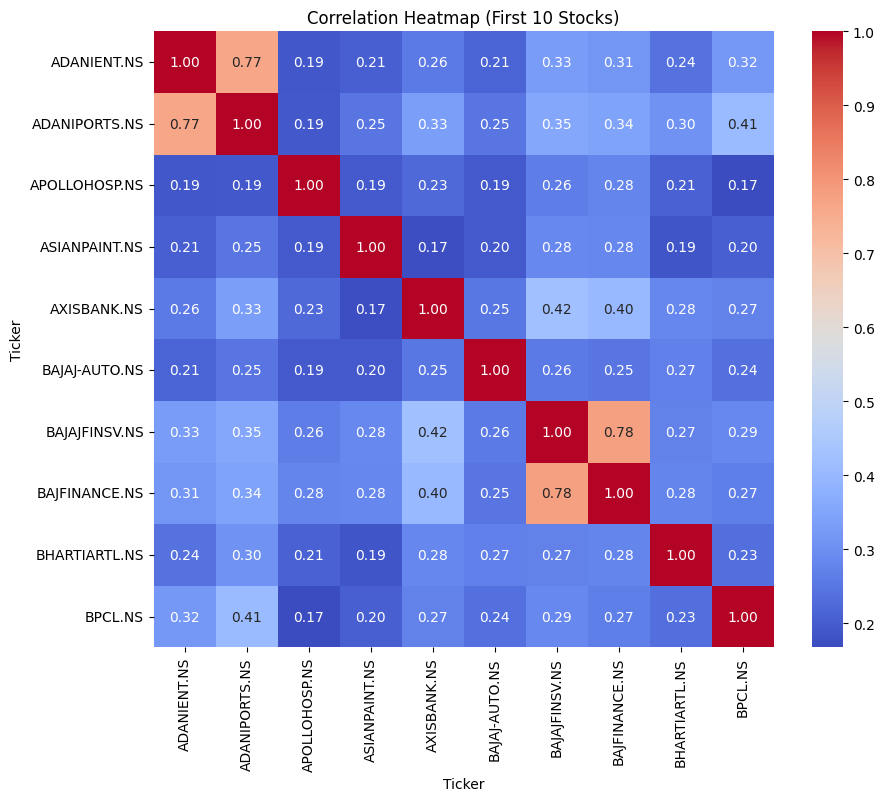

In [20]:
# Create a Pivot Table: Dates as rows, Tickers as columns, Values as 'Daily Returns'
pivot_returns = df_prices.pivot(index='Date', columns='Ticker', values='Daily_Return')

# Calculate Correlation Matrix
correlation_matrix = pivot_returns.corr()

# Plot Heatmap (Just plotting the first 10 stocks to keep it readable)
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix.iloc[:10, :10], annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap (First 10 Stocks)")
plt.show()

# 6. Exporting Data

In [22]:
# 1. Fill NaN values (The first 200 days will have NaNs for MA_200)
# We can fill them with 0 or drop them. For Power BI, dropping the initial rows is often cleaner 
# to avoid weird lines starting at 0.
df_clean = df_prices.dropna().copy()

# 2. Save the Main Fact Table
df_clean.to_csv('data/nifty50_fact_table.csv', index=False)

print(f"Final dataset exported to 'data/nifty50_fact_table.csv'")
print(f"Total Rows: {len(df_clean)}")

Final dataset exported to 'data/nifty50_fact_table.csv'
Total Rows: 50910
